In [ ]:
import pandas as pd

# 讀取資料
df = pd.read_csv(
    r"C:\Users\allen\OneDrive\Desktop\研究所\品管\open1999_202604.csv",
    encoding="big5"
)
df2 = pd.read_csv(
    r"C:\Users\allen\OneDrive\Desktop\研究所\品管\open1999_202603.csv",
    encoding="big5"
)
# 顯示前5筆
display(df.head())
display(df2.head())

# 欄位名稱
print(df.columns)

,案件編號,派工項目,案件地址,立案日期,立案時間
0,2.026040e+12,大型廢棄物清運聯繫,大同區萬全街５２之１號二樓,20260430,235842
1,2.026040e+12,大型廢棄物清運聯繫,大安區信義路四段６０之８０號6樓,20260430,235640
2,2.026040e+12,大型廢棄物清運聯繫,中山區復興北路２０４號四樓之3,20260430,235323
3,2.026040e+12,交通號誌異常,北投區臺北市臺北市北投區洲美里Hemei St211–225,20260430,235056
4,2.026040e+12,大型廢棄物清運聯繫,中山區敬業三路１６２巷３７號5樓,20260430,234624


,案件編號,派工項目,案件地址,立案日期,立案時間
0,2026033110475,大型廢棄物清運聯繫,南港區南港路三段３２６號5樓,20260331,235934
1,2026033110474,場所與設施噪音舉發,萬華區峨眉街１３號,20260331,234639
2,2026033110473,場所與設施噪音舉發,中山區臺北市臺北市中山區正義里林森北路145巷35號,20260331,234226
3,2026033110472,污染舉發,大安區忠孝東路四段２２３巷４６號,20260331,234021
4,2026033110471,場所與設施噪音舉發,萬華區108台灣臺北市萬華區西園路二段281巷31號二樓號,20260331,233227


Index(['案件編號', '派工項目', '案件地址', '立案日期', '立案時間'], dtype='object')


In [2]:
# 轉 datetime
df['立案日期'] = pd.to_datetime(
    df['立案日期'].astype(str),
    format='%Y%m%d'
)
df2['立案日期'] = pd.to_datetime(
    df2['立案日期'].astype(str),
    format='%Y%m%d'
)
# 建立星期欄位
df['weekday'] = df['立案日期'].dt.day_name()
df2['weekday'] = df2['立案日期'].dt.day_name()
# 檢查
print(df['weekday'].value_counts())
print(df2['weekday'].value_counts())

weekday
Thursday     2249
Wednesday    2215
Monday       2134
Tuesday      1947
Friday       1795
Sunday       1482
Saturday     1444
Name: count, dtype: int64
weekday
Monday       2679
Tuesday      2245
Sunday       1916
Thursday     1881
Wednesday    1800
Friday       1729
Saturday     1550
Name: count, dtype: int64


In [3]:
check_sheet = pd.crosstab(
    df['派工項目'],
    df['weekday']
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

check_sheet = check_sheet.reindex(
    columns=weekday_order,
    fill_value=0
)

check_sheet['TOTAL'] = check_sheet.sum(axis=1)

check_sheet = check_sheet.sort_values(
    by='TOTAL',
    ascending=False
)

display(check_sheet.head(10))

weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,TOTAL
派工項目,,,,,,,,
大型廢棄物清運聯繫,1287,1119,1247,1241,967,714,772,7347
場所與設施噪音舉發,216,188,251,263,191,264,234,1607
污染舉發,122,122,124,132,107,93,83,783
道路散落物或油漬處理,112,92,98,127,114,80,77,700
鄰里無主垃圾清運,107,113,102,111,84,55,51,623
路燈不亮或損壞,73,72,88,86,65,70,70,524
動物救援,45,51,52,56,42,42,60,348
市區道路坑洞處理,36,41,47,59,37,20,13,253
交通號誌異常,26,38,40,28,50,31,30,243


In [4]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

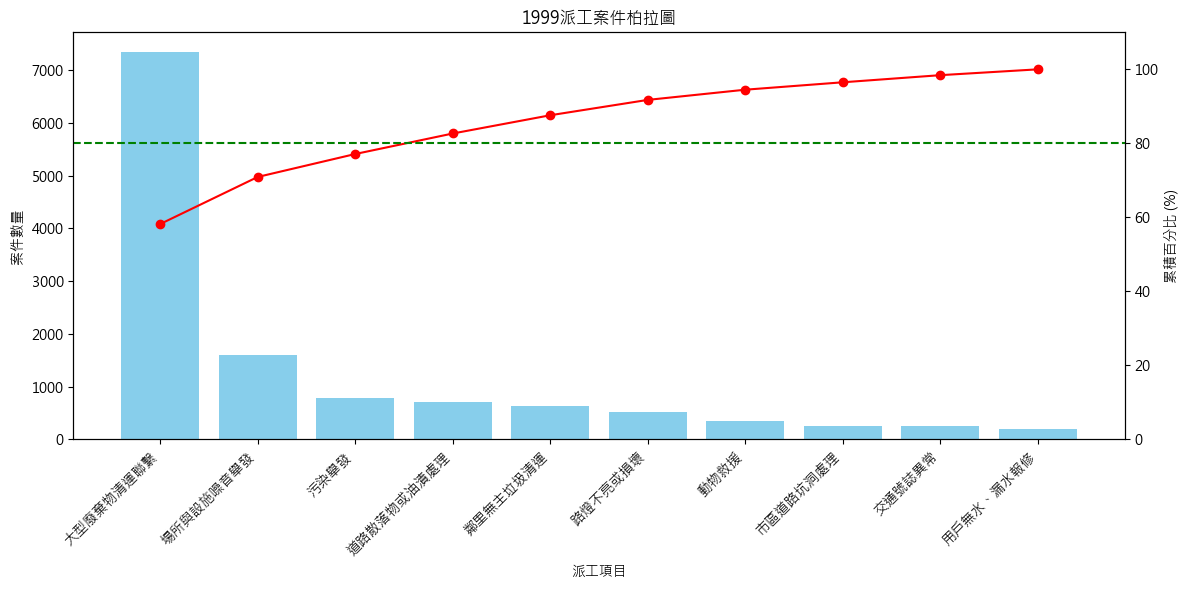

In [5]:
# 前10名派工項目
pareto_data = (
    df['派工項目']
    .value_counts()
    .head(10)
)

# 累積百分比
cum_percentage = (
    pareto_data.cumsum()
    / pareto_data.sum()
    * 100
)

# 畫圖
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    pareto_data.index,
    pareto_data.values,
    color='skyblue'
)

ax1.set_xlabel('派工項目')
ax1.set_ylabel('案件數量')
ax1.set_title('1999派工案件柏拉圖')

plt.xticks(rotation=45, ha='right')

# 第二軸
ax2 = ax1.twinx()

ax2.plot(
    pareto_data.index,
    cum_percentage,
    color='red',
    marker='o'
)

ax2.set_ylabel('累積百分比 (%)')
ax2.set_ylim(0, 110)

# 80%參考線
ax2.axhline(
    y=80,
    color='green',
    linestyle='--'
)

plt.tight_layout()
plt.show()

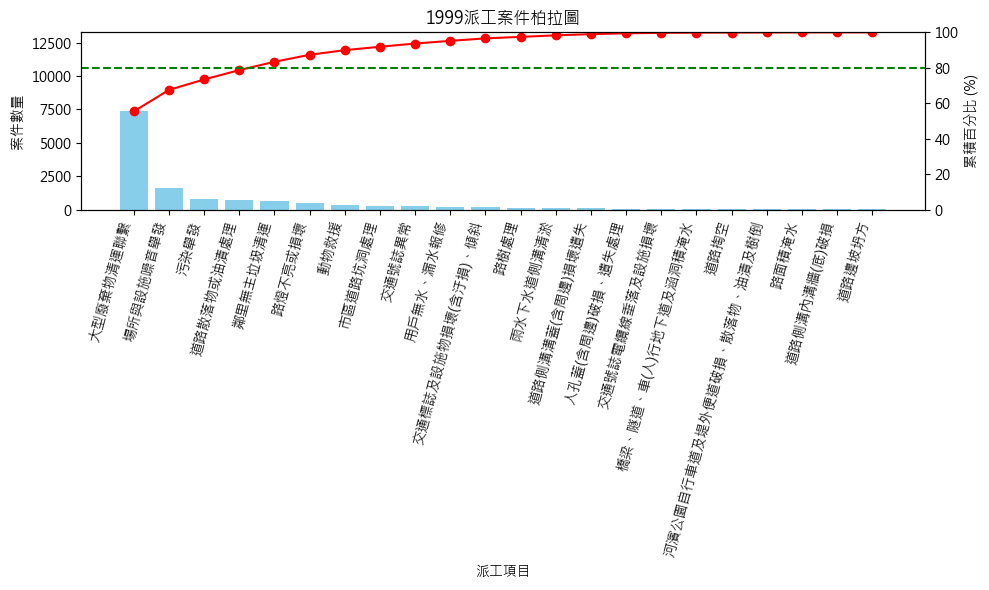

In [10]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 全部派工項目統計
pareto_data = df['派工項目'].value_counts()
total_count = pareto_data.sum()

# 累積案件數與累積百分比
cum_count = pareto_data.cumsum()
cum_percentage = cum_count / total_count * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

# 長條圖
ax1.bar(
    pareto_data.index,
    pareto_data.values,
    color='skyblue'
)

ax1.set_xlabel('派工項目')
ax1.set_ylabel('案件數量')
ax1.set_title('1999派工案件柏拉圖')
ax1.set_ylim(0, total_count)

plt.xticks(rotation=75, ha='right')

# 紅線用左軸：累積案件數
ax1.plot(
    pareto_data.index,
    cum_count,
    color='red',
    marker='o'
)

# 右軸：累積百分比
ax2 = ax1.twinx()
ax2.set_ylim(0, 100)
ax2.set_ylabel('累積百分比 (%)')

# 80%線
ax2.axhline(
    y=80,
    color='green',
    linestyle='--'
)

plt.tight_layout()
plt.show()

In [6]:
# 篩選大型廢棄物案件
bulk_waste = df[
    df['派工項目'] == '大型廢棄物清運聯繫'
]

# 每天案件數
daily_counts = (
    bulk_waste
    .groupby('立案日期')
    .size()
)

display(daily_counts.head())

立案日期
2026-04-01    231
2026-04-02    258
2026-04-03    210
2026-04-04    108
2026-04-05    145
dtype: int64

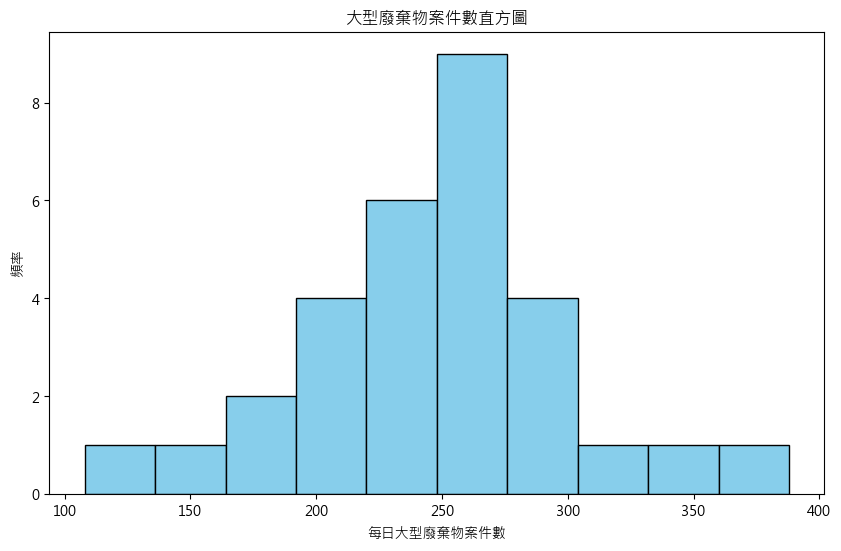

In [7]:
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 畫直方圖
plt.figure(figsize=(10,6))

plt.hist(
    daily_counts,
    bins=10,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('每日大型廢棄物案件數')
plt.ylabel('頻率')
plt.title('大型廢棄物案件數直方圖')

plt.show()

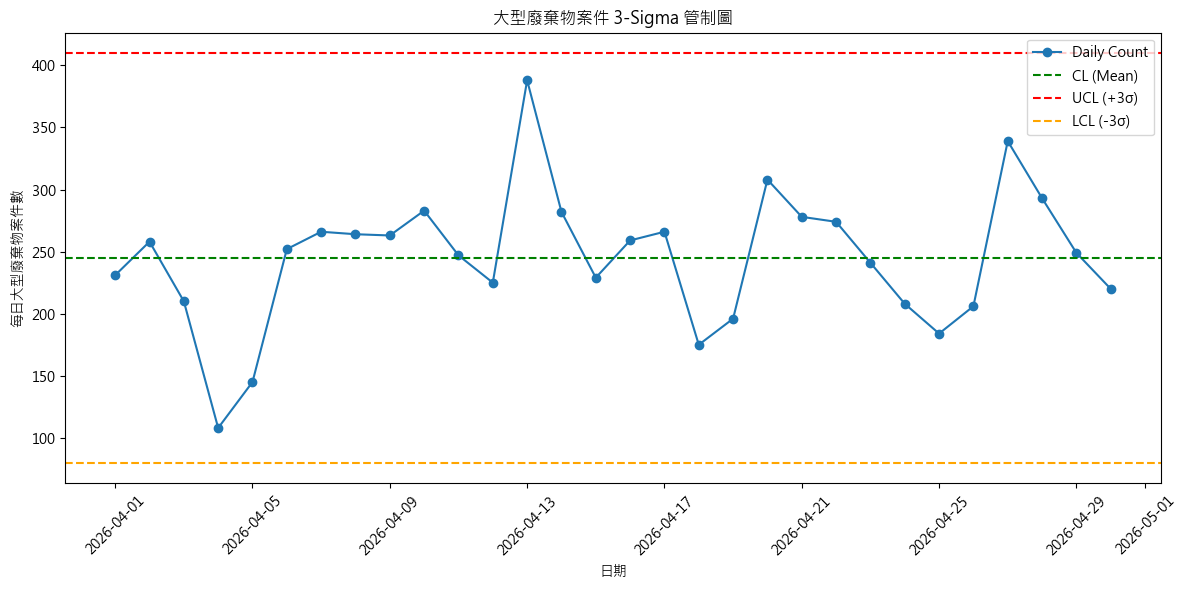

平均值 CL = 244.90
UCL = 409.88
LCL = 79.92


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 篩選大型廢棄物案件
bulk_waste = df[
    df['派工項目'] == '大型廢棄物清運聯繫'
]

# 每日案件數
daily_counts = (
    bulk_waste
    .groupby('立案日期')
    .size()
)

# 計算平均與標準差
mean = daily_counts.mean()
std = daily_counts.std()

# 3-sigma 管制界限
UCL = mean + 3 * std
LCL = mean - 3 * std

# LCL不能小於0
LCL = max(LCL, 0)

# 畫圖
plt.figure(figsize=(12,6))

# 每日案件數
plt.plot(
    daily_counts.index,
    daily_counts.values,
    marker='o',
    linestyle='-',
    label='Daily Count'
)

# 中心線
plt.axhline(
    mean,
    color='green',
    linestyle='--',
    label='CL (Mean)'
)

# 上管制界限
plt.axhline(
    UCL,
    color='red',
    linestyle='--',
    label='UCL (+3σ)'
)

# 下管制界限
plt.axhline(
    LCL,
    color='orange',
    linestyle='--',
    label='LCL (-3σ)'
)

plt.xlabel('日期')
plt.ylabel('每日大型廢棄物案件數')
plt.title('大型廢棄物案件 3-Sigma 管制圖')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 印出數值
print(f'平均值 CL = {mean:.2f}')
print(f'UCL = {UCL:.2f}')
print(f'LCL = {LCL:.2f}')

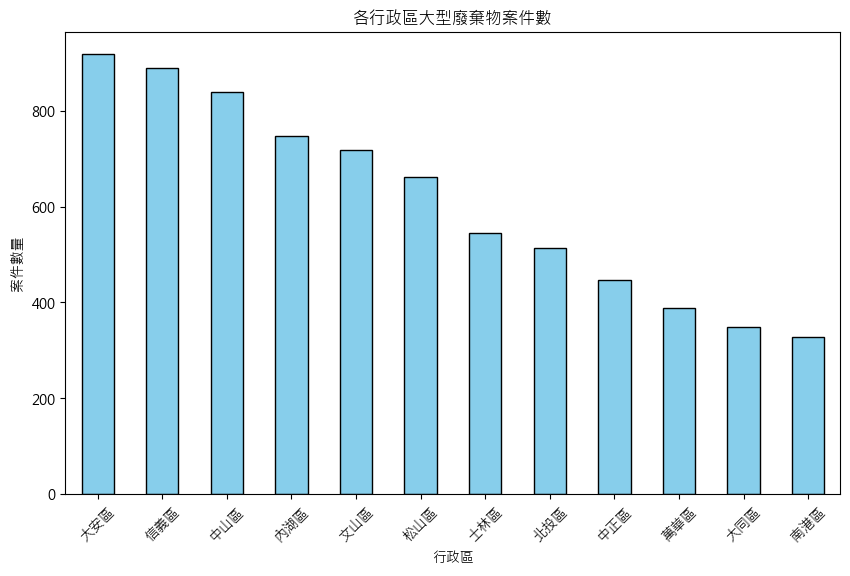

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 只分析大型廢棄物
bulk_waste = df[
    df['派工項目'] == '大型廢棄物清運聯繫'
].copy()

# 從地址抓行政區
districts = [
    '中正區','大同區','中山區','松山區',
    '大安區','萬華區','信義區','士林區',
    '北投區','內湖區','南港區','文山區'
]

def extract_district(address):
    for d in districts:
        if d in str(address):
            return d
    return '其他'

bulk_waste['行政區'] = bulk_waste['案件地址'].apply(extract_district)

# 統計案件數
district_counts = (
    bulk_waste['行政區']
    .value_counts()
)

# 畫圖
plt.figure(figsize=(10,6))

district_counts.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('行政區')
plt.ylabel('案件數量')
plt.title('各行政區大型廢棄物案件數')

plt.xticks(rotation=45)

plt.show()

In [3]:
phase1 = df2[
    df2['派工項目'] == '大型廢棄物清運聯繫'
]

phase2 = df[
    df['派工項目'] == '大型廢棄物清運聯繫'
]

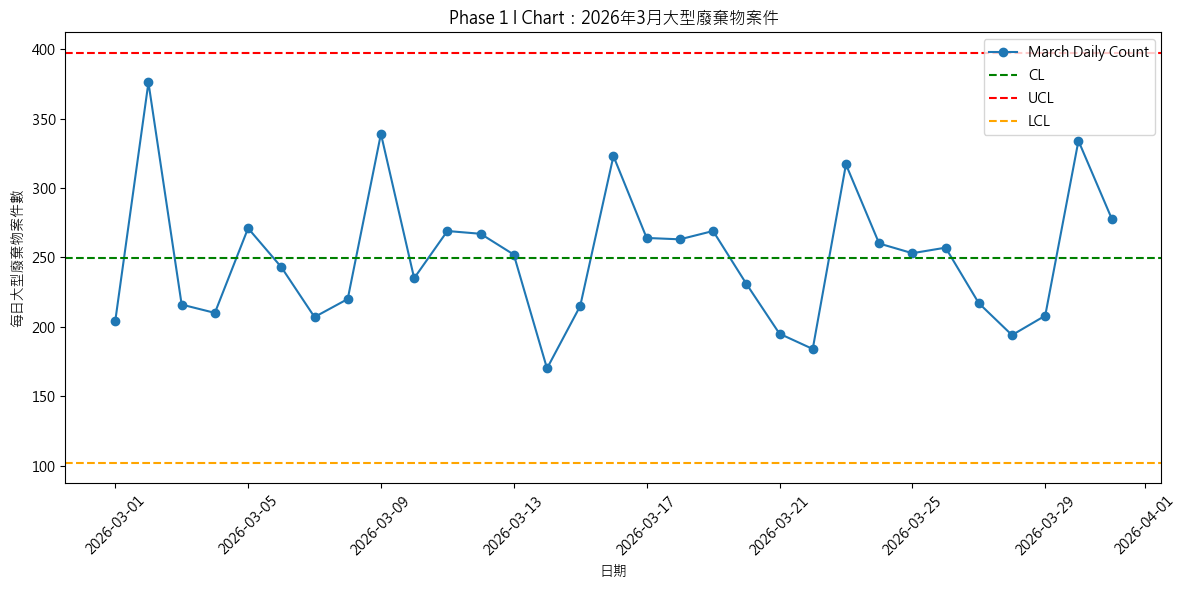

Phase 1 CL = 249.71
Phase 1 UCL = 397.37
Phase 1 LCL = 102.05


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# Phase 1：3月大型廢棄物案件
phase1 = df2[df2['派工項目'] == '大型廢棄物清運聯繫']

phase1_daily = (
    phase1
    .groupby('立案日期')
    .size()
)

# 建立 Phase 1 管制界限
CL = phase1_daily.mean()
sigma = phase1_daily.std()
UCL = CL + 3 * sigma
LCL = max(CL - 3 * sigma, 0)

# 畫 Phase 1 I Chart
plt.figure(figsize=(12,6))

plt.plot(
    phase1_daily.index,
    phase1_daily.values,
    marker='o',
    label='March Daily Count'
)

plt.axhline(CL, color='green', linestyle='--', label='CL')
plt.axhline(UCL, color='red', linestyle='--', label='UCL')
plt.axhline(LCL, color='orange', linestyle='--', label='LCL')

plt.xlabel('日期')
plt.ylabel('每日大型廢棄物案件數')
plt.title('Phase 1 I Chart：2026年3月大型廢棄物案件')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Phase 1 CL = {CL:.2f}')
print(f'Phase 1 UCL = {UCL:.2f}')
print(f'Phase 1 LCL = {LCL:.2f}')

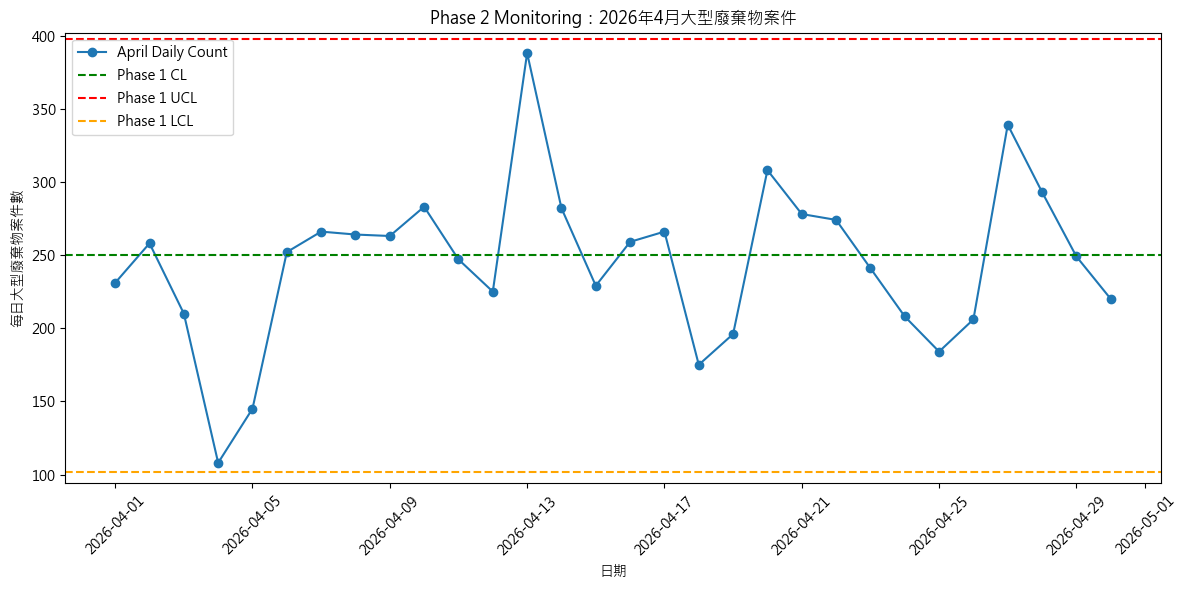

Out of Control 點：


Series([], dtype: int64)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# Phase 2：4月大型廢棄物案件
phase2 = df[df['派工項目'] == '大型廢棄物清運聯繫']

phase2_daily = (
    phase2
    .groupby('立案日期')
    .size()
)

# 畫 Phase 2 Monitoring Chart
plt.figure(figsize=(12,6))

plt.plot(
    phase2_daily.index,
    phase2_daily.values,
    marker='o',
    label='April Daily Count'
)

# 注意：這裡用的是 Phase 1 的 CL/UCL/LCL
plt.axhline(CL, color='green', linestyle='--', label='Phase 1 CL')
plt.axhline(UCL, color='red', linestyle='--', label='Phase 1 UCL')
plt.axhline(LCL, color='orange', linestyle='--', label='Phase 1 LCL')

plt.xlabel('日期')
plt.ylabel('每日大型廢棄物案件數')
plt.title('Phase 2 Monitoring：2026年4月大型廢棄物案件')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 找出 Out of Control 點
ooc = phase2_daily[
    (phase2_daily > UCL) |
    (phase2_daily < LCL)
]

print("Out of Control 點：")
display(ooc)

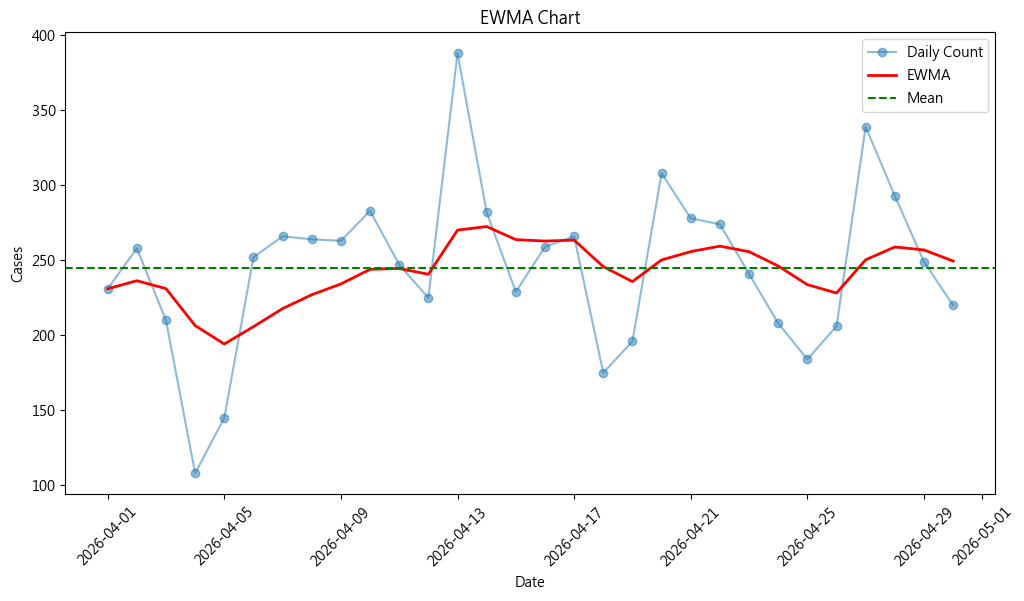

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

x = phase2_daily.values

lambda_ = 0.2

ewma = [x[0]]

for i in range(1, len(x)):
    ewma.append(
        lambda_ * x[i]
        + (1 - lambda_) * ewma[i-1]
    )

plt.figure(figsize=(12,6))

plt.plot(
    phase2_daily.index,
    x,
    marker='o',
    label='Daily Count',
    alpha=0.5
)

plt.plot(
    phase2_daily.index,
    ewma,
    color='red',
    linewidth=2,
    label='EWMA'
)

plt.axhline(
    np.mean(x),
    color='green',
    linestyle='--',
    label='Mean'
)

plt.title('EWMA Chart')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()

plt.xticks(rotation=45)

plt.show()

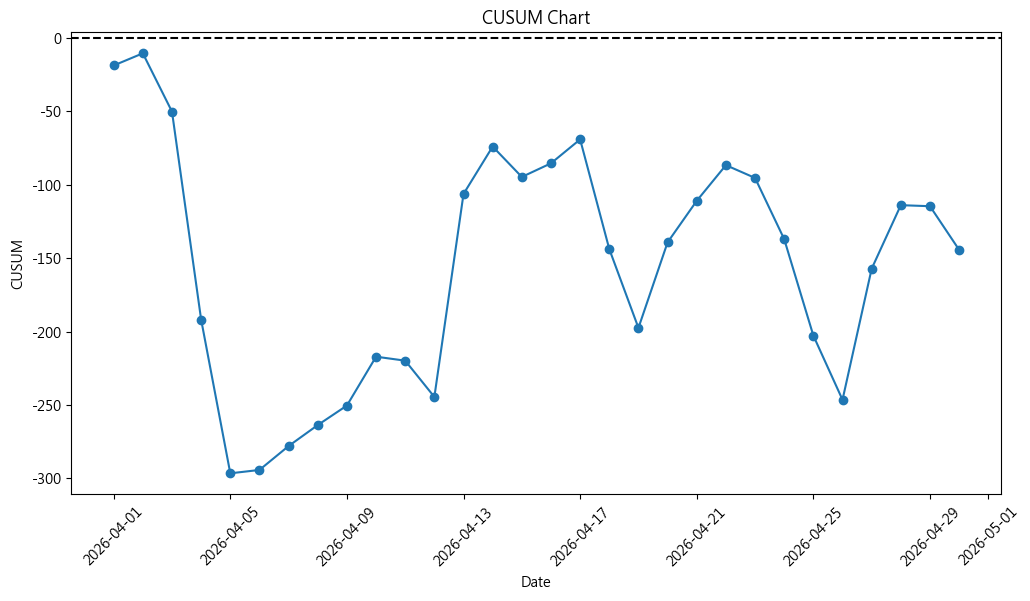

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

x = phase2_daily.values

target = np.mean(phase1_daily)

cusum = np.cumsum(
    x - target
)

plt.figure(figsize=(12,6))

plt.plot(
    phase2_daily.index,
    cusum,
    marker='o'
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title('CUSUM Chart')
plt.xlabel('Date')
plt.ylabel('CUSUM')

plt.xticks(rotation=45)

plt.show()